<h1><center>Churn Prediction (Statistical Testing, Stacking Ensemble) </center></h1>

<center><img src="https://uploads-ssl.webflow.com/60d45d63543dd9baaad4cb28/60d85fd90743e2299c711be5_1%20dqSLRSEC2GDV9bw_PplCYQ.png" align="center"/></center>

<a id='6'></a>
# 6 Bivariate Analysis

In this section, I did an extensive statistical analysis with various hypotheses testing based on paired data types like - 

* numerical and numerical data
* numerical and ordinal data
* ordinal and ordinal data
* categorical and categorical data


General Hypotheses - 

* H0: the two samples are independent
* H1: there is a dependency between the samples

<a id='6.1'></a>
## 6.1 List Feature Based on Types

In [42]:
# Check cardinality of categorical variables 
target_col_filter = df_churn.loc[:, df_churn.columns != 'Churn']


cat_cols = list(set(target_col_filter.columns) - set(target_col_filter._get_numeric_data().columns))
num_cols = list(set(target_col_filter._get_numeric_data().columns) - set({'SeniorCitizen'})) # already converted to integer


# Get number of unique entries in each column with categorical data
object_nunique = list(map(lambda col: target_col_filter[col].nunique(), cat_cols))
dict_features_by_col = dict(zip(cat_cols, object_nunique))


# Print number of unique entries by column, in ascending order
print(sorted(dict_features_by_col.items(), key=lambda x: x[1]))


ordinal_cols = ['tenure-binned', 'MonthlyCharges-binned', 'TotalCharges-binned']
dichotomous_cols = [cat for cat in cat_cols if df_churn[cat].value_counts().count() == 2]
polytomous_cols = list(set(cat_cols) - set(dichotomous_cols) - set(ordinal_cols))


print("Categorical Columns".ljust(left_padding), cat_cols)
print("Numerical Columns".ljust(left_padding), num_cols)
print("Ordinal Columns".ljust(left_padding), ordinal_cols)
print("Dichotomous Columns".ljust(left_padding), dichotomous_cols)
print("Polytomous Columns".ljust(left_padding), polytomous_cols)

[('PhoneService', 2), ('PaperlessBilling', 2), ('gender', 2), ('Partner', 2), ('Dependents', 2), ('MultipleLines', 3), ('OnlineSecurity', 3), ('StreamingMovies', 3), ('MonthlyCharges-binned', 3), ('TotalCharges-binned', 3), ('DeviceProtection', 3), ('StreamingTV', 3), ('OnlineBackup', 3), ('Contract', 3), ('TechSupport', 3), ('tenure-binned', 3), ('InternetService', 3), ('PaymentMethod', 4)]
Categorical Columns   ['PhoneService', 'MultipleLines', 'PaperlessBilling', 'OnlineSecurity', 'StreamingMovies', 'MonthlyCharges-binned', 'TotalCharges-binned', 'DeviceProtection', 'StreamingTV', 'gender', 'OnlineBackup', 'Partner', 'PaymentMethod', 'Contract', 'TechSupport', 'tenure-binned', 'Dependents', 'InternetService']
Numerical Columns     ['MonthlyCharges', 'TotalCharges', 'tenure']
Ordinal Columns       ['tenure-binned', 'MonthlyCharges-binned', 'TotalCharges-binned']
Dichotomous Columns   ['PhoneService', 'PaperlessBilling', 'gender', 'Partner', 'Dependents']
Polytomous Columns    ['Multi

**Categorical Columns**
> 'TechSupport', 'DeviceProtection', 'Contract', 'PaperlessBilling', 'TotalCharges-binned', <br>'gender', 'OnlineBackup', 'InternetService', 'StreamingTV', 'tenure-binned', <br>'Dependents', 'PhoneService', 'StreamingMovies', 'MultipleLines', 'Partner', <br>'MonthlyCharges-binned', 'OnlineSecurity', 'PaymentMethod'

**Numerical Columns**
> 'MonthlyCharges', 'tenure', 'TotalCharges'

**Ordinal Columns**
> tenure-binned', 'MonthlyCharges-binned', 'TotalCharges-binned'

**Dichotomous Columns**
> 'PaperlessBilling', 'gender', 'Dependents', 'PhoneService', 'Partner'

**Polytomous Columns**
> 'TechSupport', 'StreamingMovies', 'DeviceProtection', 'MultipleLines', 'Contract',<br> 'InternetService', 'OnlineSecurity', 'StreamingTV', 'PaymentMethod', 'OnlineBackup'

<a id='6.2'></a>
## 6.2 Numerical & Numerical

<a id='6.2.1'></a>
### 6.2.1 Spearman rank-order correlation
---
AKA Spearman's rho or Spearman correlation coefficient\
Applied to **Continuous or ordinal**

<br>

**Unlike the Pearson correlation**, the Spearman correlation does not assume that both datasets are **normally distributed**

Pearson correlation assumes normality, linearity and homoscedasticity.Pearson's correlation is also not able to tell the difference between dependent and independent variables

Hypotheses -

* H0: the two samples do not have monotonic relationship
* H1: there is a monotonic relationship between the samples

For Pearson r correlation, both variables should be normally distributed

According to the normality test tenure, MonthlyCharges and TotalCharges columns are **not normally distributed** 

In [43]:
def cal_spearmanr(c1, c2):

  alpha = 0.05

  correlation, p_value = stats.spearmanr(df_churn[c1], df_churn[c2])

  print(f'{c1}, {c2} correlation : {correlation}, p : {p_value}')

  if p_value > alpha:
    print('Probably do not have monotonic relationship (fail to reject H0)')
  else:
    print('Probably have monotonic relationship (reject H0)')

In [44]:
cal_spearmanr('tenure','MonthlyCharges')

tenure, MonthlyCharges correlation : 0.27641678933130215, p : 1.0271266876409408e-123
Probably have monotonic relationship (reject H0)


In [45]:
cal_spearmanr('tenure','TotalCharges')

tenure, TotalCharges correlation : 0.8896957900597577, p : 0.0
Probably have monotonic relationship (reject H0)


In [46]:
cal_spearmanr('MonthlyCharges','TotalCharges')

MonthlyCharges, TotalCharges correlation : 0.638028390201301, p : 0.0
Probably have monotonic relationship (reject H0)


<a id='6.3'></a>
## 6.3 Numerical & Categorical

<a id='6.3.1'></a>
### 6.3.1 Kendall rank correlation coefficient 
---
AKA **Kendall's τ** or **Kendall's Tau**

Kendall’s Tau is often used for correlation on continuous data if there are outliers in the data

A τ test is a non-parametric hypothesis test for statistical dependence based on the τ coefficient

Variable would be **continuous or ordinal**

Ordinal variable examples - 
* age, weight, height, test scores, survey scores, yearly salary, etc
* education level (GDE/Bachelors/Masters/PhD), income level (if grouped into high/medium/low) etc

In this dataset there are three ordinal features : 
* tenure-binned  
* MonthlyCharges-binned 
* TotalCharges-binned

In [47]:
def kendall_rank_correlation(feature1, feature2):

  coef, p_value = stats.kendalltau(df_churn[feature1], df_churn[feature2])
  print(f"Correlation between {feature1} and {feature2} ")
  print('Kendall correlation coefficient = %.5f, p = %.5f' % (coef, p_value))

  # interpret the significance
  alpha = 0.05
  if p_value > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p_value)
  else:
    print('Samples are correlated (reject H0) p=%.3f' % p_value)
  print('----\n')

In [48]:
ordinal_features = ['tenure-binned','MonthlyCharges-binned', 'TotalCharges-binned']

for ord in ordinal_features:
  printmd(f"Correlation with **{ord}**")
  kendall_rank_correlation('tenure',ord)
  kendall_rank_correlation('MonthlyCharges',ord)
  kendall_rank_correlation('TotalCharges',ord)

Correlation with **tenure-binned**

Correlation between tenure and tenure-binned 
Kendall correlation coefficient = -0.28746, p = 0.00000
Samples are correlated (reject H0) p=0.000
----

Correlation between MonthlyCharges and tenure-binned 
Kendall correlation coefficient = -0.10710, p = 0.00000
Samples are correlated (reject H0) p=0.000
----

Correlation between TotalCharges and tenure-binned 
Kendall correlation coefficient = -0.23680, p = 0.00000
Samples are correlated (reject H0) p=0.000
----



Correlation with **MonthlyCharges-binned**

Correlation between tenure and MonthlyCharges-binned 
Kendall correlation coefficient = -0.16485, p = 0.00000
Samples are correlated (reject H0) p=0.000
----

Correlation between MonthlyCharges and MonthlyCharges-binned 
Kendall correlation coefficient = -0.22506, p = 0.00000
Samples are correlated (reject H0) p=0.000
----

Correlation between TotalCharges and MonthlyCharges-binned 
Kendall correlation coefficient = -0.20858, p = 0.00000
Samples are correlated (reject H0) p=0.000
----



Correlation with **TotalCharges-binned**

Correlation between tenure and TotalCharges-binned 
Kendall correlation coefficient = 0.07424, p = 0.00000
Samples are correlated (reject H0) p=0.000
----

Correlation between MonthlyCharges and TotalCharges-binned 
Kendall correlation coefficient = 0.00298, p = 0.75152
Samples are uncorrelated (fail to reject H0) p=0.752
----

Correlation between TotalCharges and TotalCharges-binned 
Kendall correlation coefficient = 0.12334, p = 0.00000
Samples are correlated (reject H0) p=0.000
----



<a id='6.3.2'></a>
### 6.3.2 Mann-Whitney U Test

The Mann-Whitney U test is a **nonparametric** statistical significance test for determining whether two independent samples were drawn from a population with the same distribution.

The test determines whether the medians of two or more groups are different.

**NB** : For the test to be effective, it requires **at least 20 observations** in each data sample.

* Fail to Reject H0: Sample distributions are equal. (or sample distributions are likely drawn from the same population)
* Reject H0: Sample distributions are not equal.

or

* H0: population medians are equal.
* H1: population medians are not equal.

### Correlation with Target (Dichotomous)

In [49]:
def mannwhitneyu_correlation(feature1):
  stat, p_value = stats.mannwhitneyu(df_churn[feature1], (df_churn['Churn'] == 'Yes').astype(int))
  print(f"Correlation between {feature1} and Churn")
  print('Statistics = %.5f, p = %.5f' % (stat, p_value))
  
  # interpret the significance
  alpha = 0.05
  if p_value > alpha:
      print('Same distribution (fail to reject H0)')
  else:
      print('Different distribution (reject H0)')
  print('----\n') 

In [50]:
numerical_features = ['tenure','MonthlyCharges', 'TotalCharges']

for num in numerical_features:
  printmd(f"Correlation with **{num}**")
  mannwhitneyu_correlation(num)

Correlation with **tenure**

Correlation between tenure and Churn
Statistics = 48981984.50000, p = 0.00000
Different distribution (reject H0)
----



Correlation with **MonthlyCharges**

Correlation between MonthlyCharges and Churn
Statistics = 49603849.00000, p = 0.00000
Different distribution (reject H0)
----



Correlation with **TotalCharges**

Correlation between TotalCharges and Churn
Statistics = 49554833.00000, p = 0.00000
Different distribution (reject H0)
----



**Biserial correlation**

The point biserial correlation is used to measure the relationship between a **binary variable, x, and a continuous variable, y**. Like other correlation coefficients, this one varies between -1 and +1 with 0 implying no correlation. Correlations of -1 or +1 imply a determinative relationship.

NB: point-biserial correlation is conducted with the Pearson correlation formula except that one of the variables is dichotomous

The assumptions for Point-Biserial correlation include:

* Continuous and Binary
* **Normally Distributed** (In our case not normal)
* No Outliers
* Equal Variances

Options to normalize a non-normal distribution - 
 
* Log transform
* Square root transform
* Box cox (can only be applied to strictly positive data)
* Yeo Johnson (both positive and negative)

In [51]:
# https://stackoverflow.com/questions/53624804/how-to-normalize-a-non-normal-distribution

data = df_churn['MonthlyCharges'].to_numpy()
pt = PowerTransformer(method='yeo-johnson') # ‘box-cox’, 'yeo-johnson'
data = data.reshape(-1, 1)
pt.fit(data)
transformed_data = pt.transform(data)

transformed_k2, transformed_p = stats.normaltest(transformed_data)

# other methods to transform into gaussian distribution

# stats.normaltest(np.log(df_churn['MonthlyCharges']))
# stats.normaltest(np.sqrt(df_churn['MonthlyCharges'])
# stats.normaltest(stats.boxcox(df_churn['MonthlyCharges'])[0])

# all other methods failed to convert into gaussian


alpha = 0.05
if transformed_p > alpha:
	print('Sample looks Gaussian (fail to reject H0)')
else:
	print('Sample does not look Gaussian (reject H0)')

Sample does not look Gaussian (reject H0)


**Since the numerical columns can not be converted to gaussian distribution, point biseral correlation test can not be performed**

<a id='6.3.3'></a>
### 6.3.3 Polytomous(Nominal) with numeric

For a dichotomous categorical variable and a continuous variable we can calculate a Pearson correlation if the categorical variable has a 0/1-coding for the categories. This correlation is then also known as a point-biserial correlation coefficient. (parametric test)

But when we have **more than two categories** for the categorical variable the Pearson correlation is not appropriate anymore. \
We should then use **eta-squared, or eta**, as an effect-size measure for the relationship of a **categorical variable and a continuous variable**.


In [52]:
def correlation_ratio(categories, measurements):
    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat)+1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(0,cat_num):
        cat_measures = measurements[np.argwhere(fcat == i).flatten()]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.average(cat_measures)
    y_total_avg = np.sum(np.multiply(y_avg_array,n_array))/np.sum(n_array)
    numerator = np.sum(np.multiply(n_array,np.power(np.subtract(y_avg_array,y_total_avg),2)))
    denominator = np.sum(np.power(np.subtract(measurements,y_total_avg),2))
    if numerator == 0:
        eta = 0.0
    else:
        eta = np.sqrt(numerator/denominator)
    return eta

In [53]:
correlation_ratio(df_churn['PaymentMethod'], df_churn['MonthlyCharges'])

np.float64(0.40127388087245935)

In [54]:
correlation_ratio(df_churn['PaymentMethod'], df_churn['TotalCharges'])

np.float64(0.35074070554475645)

In [55]:
correlation_ratio(df_churn['PaymentMethod'], df_churn['tenure'])

np.float64(0.3998293691962001)

<a id='6.4'></a>
## 6.4 Dichotomous & Dichotomous

In classification, when both of them are categorical, then the strength of the relationship between them can be measured using a **Chi-square test**

<a id='6.4.1'></a>
### 6.4.1 Phi’s correlation 
---
AKA **Matthews correlation coefficient (MCC)**


In [56]:
printmd("**Correlation Between Dichotomous Features with Target : Churn**")

for col in dichotomous_cols:
  print(col.ljust(left_padding), matthews_corrcoef(df_churn[col], df_churn['Churn']))

**Correlation Between Dichotomous Features with Target : Churn**

PhoneService          0.01194198002900308
PaperlessBilling      0.1918253316664679
gender                0.0
Partner               -0.15044754495917656
Dependents            -0.16422140157972528


<a id='6.5'></a>
## 6.5 Categorical & categorical 

<a id='6.5.1'></a>
### 6.5.1 Chi-Square

detect independence between 2 categorical variables, 2x2 or 2xMany

Test statistic in the context of the chi-squared distribution with the requisite number of degrees of freedom

* If Statistic >= Critical Value: significant result, reject null hypothesis (H0), dependent.
* If Statistic < Critical Value: not significant result, fail to reject null hypothesis (H0), independent.

In terms of a p-value and a chosen significance level (alpha):

* If p-value <= alpha: significant result, reject null hypothesis (H0), dependent.
* If p-value > alpha: not significant result, fail to reject null hypothesis (H0), independent

![image](https://user-images.githubusercontent.com/40615350/114787798-2a027900-9da2-11eb-972e-c5e52a9a628f.png)

In [57]:
# alpha/significance = 0.05
# If p-value <= alpha: significant result, reject null hypothesis (H0), dependent
# If p-value > alpha: not significant result, fail to reject null hypothesis (H0), independent

def calculate_chi_square(feature1, feature2='Churn'):
  printmd(f"Correlation between **{feature1}** and **{feature2}**")
  crosstab = pd.crosstab(df_churn[feature1], df_churn[feature2])
  # display(crosstab)
  stat, p, dof, expected = stats.chi2_contingency(crosstab,correction=True)


  print(f'p-value : {p}, degree of freedom: {dof}')
  # print("expected frequencies :\n", expected)

  # interpret test-statistic
  prob = 0.95
  critical = stats.chi2.ppf(prob, dof)
  print('probability=%.3f, critical=%.3f, stat=%.3f' % (prob, critical, stat))

  if abs(stat) >= critical:
    print('Dependent (reject H0)')
  else:
    print('Independent (fail to reject H0)')
  
  # interpret p-value
  alpha = 1.0 - prob
  
  print('significance=%.3f, p=%.3f' % (alpha, p))
  if p <= alpha:
    print('Dependent (reject H0)')
  else:
    print('Independent (fail to reject H0)')
  print('-----------------------------------\n')

# credit : https://machinelearningmastery.com/chi-squared-test-for-machine-learning

#### Dichotomous Features

In [58]:
printmd("**Chi-Squre Correlation Between Dichotomous Features with Target : Churn**")

for col in dichotomous_cols:
  calculate_chi_square(col)


**Chi-Squre Correlation Between Dichotomous Features with Target : Churn**

Correlation between **PhoneService** and **Churn**

p-value : 0.3387825358066928, degree of freedom: 1
probability=0.950, critical=3.841, stat=0.915
Independent (fail to reject H0)
significance=0.050, p=0.339
Independent (fail to reject H0)
-----------------------------------



Correlation between **PaperlessBilling** and **Churn**

p-value : 4.073354668665985e-58, degree of freedom: 1
probability=0.950, critical=3.841, stat=258.278
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



...

p-value : 0.48657873605618596, degree of freedom: 1
probability=0.950, critical=3.841, stat=0.484
Independent (fail to reject H0)
significance=0.050, p=0.487
Independent (fail to reject H0)
-----------------------------------



Correlation between **Partner** and **Churn**

p-value : 2.1399113440759935e-36, degree of freedom: 1
probability=0.950, critical=3.841, stat=158.733
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



Correlation between **Dependents** and **Churn**

p-value : 4.9249216612154196e-43, degree of freedom: 1
probability=0.950, critical=3.841, stat=189.129
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



**With 5% significance level 'PhoneService' and 'gender' features are not dependent with the target : Churn**

### Polytomous Features

In [59]:
printmd("**Chi-Squre Correlation Between Polytomous Features with Target : Churn**")

for col in polytomous_cols:
  calculate_chi_square(col)

**Chi-Squre Correlation Between Polytomous Features with Target : Churn**

Correlation between **MultipleLines** and **Churn**

p-value : 0.0034643829548773, degree of freedom: 2
probability=0.950, critical=5.991, stat=11.330
Dependent (reject H0)
significance=0.050, p=0.003
Dependent (reject H0)
-----------------------------------



Correlation between **PaymentMethod** and **Churn**

p-value : 3.6823546520097993e-140, degree of freedom: 3
probability=0.950, critical=7.815, stat=648.142
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



...

p-value : 5.528994485739183e-82, degree of freedom: 2
probability=0.950, critical=5.991, stat=374.204
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



Correlation between **InternetService** and **Churn**

p-value : 9.571788222840544e-160, degree of freedom: 2
probability=0.950, critical=5.991, stat=732.310
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



Correlation between **DeviceProtection** and **Churn**

p-value : 5.505219496457244e-122, degree of freedom: 2
probability=0.950, critical=5.991, stat=558.419
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



**With 5% significance level All polytomous features are dependent with the target : Churn**

<a id='6.5.2'></a>
###  6.5.2 Cramér’s V
---
It is based on a nominal variation of **Pearson’s Chi-Square** Test\
Like correlation, Cramer’s V is symmetrical — it is insensitive to swapping x and y

Cramer's V is used to examine the association between **two categorical variables when there is more than a 2 X 2 contingency** (e.g., 2 X 3).\
In these more complicated designs, **phi correlation test** is not appropriate, but Cramer's statistic is. Cramer's V represents the association or correlation between two variables. This statistic is also referred to as **"Cramers Phi"**

To know more about this, visit this article : [the-search-for-categorical-correlation](https://towardsdatascience.com/the-search-for-categorical-correlation-a1cf7f1888c9)

In [60]:
def cramers_v(x, y):
  """ calculate Cramers V statistic for categorial-categorial association.
      uses correction from Bergsma and Wicher,
      Journal of the Korean Statistical Society 42 (2013): 323-328
  """
  confusion_matrix = pd.crosstab(x,y)
  chi2 = stats.chi2_contingency(confusion_matrix)[0]
  n = confusion_matrix.sum().sum()
  phi2 = chi2/n
  r,k = confusion_matrix.shape
  phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
  rcorr = r-((r-1)**2)/(n-1)
  kcorr = k-((k-1)**2)/(n-1)
  return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

# credit : https://stackoverflow.com/a/46498792/11105356

In [61]:
printmd("**Correlation Between Polytomous Features with Target : Churn**")
cramer_v_val_dict = {}
for col in polytomous_cols:
  cramer_v_val_dict[col] = cramers_v(df_churn[col], df_churn['Churn'])

cramer_v_val_dict_sorted = sorted(cramer_v_val_dict.items(), key=lambda x:x[1], reverse=True)

for k,v in cramer_v_val_dict_sorted:
  print(k.ljust(left_padding), v)

printmd("<br>**Contract, OnlineSecurity, TechSupport, InternetService are moderately correlated with Churn**<br>")            

**Correlation Between Polytomous Features with Target : Churn**

Contract              0.40979839182553446
OnlineSecurity        0.34701606688272874
TechSupport           0.3425261587493695
InternetService       0.3220367323307425
PaymentMethod         0.3026771381187204
OnlineBackup          0.291850036724674
DeviceProtection      0.28109492388964397
StreamingMovies       0.23035147282444215
StreamingTV           0.22990176915403474
MultipleLines         0.03639958908232507


<br>**Contract, OnlineSecurity, TechSupport, InternetService are moderately correlated with Churn**<br>

**Cramers V Heatmap on Polytomous Features and Target: Churn**

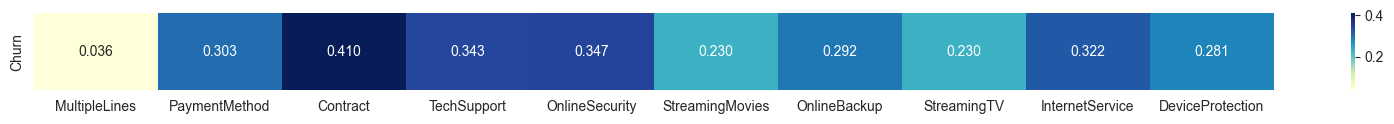

In [62]:
printmd("**Cramers V Heatmap on Polytomous Features and Target: Churn**")
cramers_v_val = pd.DataFrame(index=['Churn'], columns=polytomous_cols)

for j in range(0, len(polytomous_cols)):
    u = cramers_v(df_churn['Churn'], df_churn[polytomous_cols[j]])
    cramers_v_val.loc[:, polytomous_cols[j]] = float(np.asarray(u).ravel()[0])  # ensure float

cramers_v_val = cramers_v_val.astype(float)  # convert entire DF to float
cramers_v_val.fillna(value=np.nan, inplace=True)

plt.figure(figsize=(20, 1))
sns.heatmap(cramers_v_val, annot=True, fmt='.3f', cmap="YlGnBu")
plt.show()


#### Using Scipy Module

In [63]:
crosstab = pd.crosstab(df_churn['OnlineSecurity'], df_churn['Churn'])
display(crosstab)
printmd(f"Association between OnlineSecurity and Target:Churn **{stats.contingency.association(crosstab, method='cramer')}**")

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


Association between OnlineSecurity and Target:Churn **0.3474004326740552**

<a id='6.5.3'></a>
### 6.5.3 Uncertainty Coefficient
---


AKA **Theil’s U** - an **asymmetric** measure of association between categorical features

It is is based on the conditional entropy between x and y — or in human language, given the value of x, how many possible states does y have, and how often do they occur. 

Formaly marked as U(x|y); Just like Cramer’s V, the output value is on the range of [0,1], where 0 means that feature y provides no information about feature x, and 1 means that feature y provides full information about features x's value 

**Unlike Cramer’s V, it is asymmetric**

So we will not lose any valuable information unlike symmetric tests 

In [64]:
def conditional_entropy(x,y):
  # entropy of x given y
  y_counter = Counter(y)
  xy_counter = Counter(list(zip(x,y)))
  total_occurrences = sum(y_counter.values())
  entropy = 0
  for xy in xy_counter.keys():
      p_xy = xy_counter[xy] / total_occurrences
      p_y = y_counter[xy[1]] / total_occurrences
      entropy += p_xy * math.log(p_y/p_xy)
  return entropy

def theil_u(x,y):
  s_xy = conditional_entropy(x,y)
  x_counter = Counter(x)
  total_occurrences = sum(x_counter.values())
  p_x = list(map(lambda n: n/total_occurrences, x_counter.values()))
  s_x = stats.entropy(p_x)
  if s_x == 0:
      return 1
  else:
      return (s_x - s_xy) / s_x

In [65]:
# --- Compute Theil’s U (asymmetric association) of features → Churn ---

import numpy as np
import pandas as pd
from math import log
from collections import Counter

# choose categorical (polytomous) columns to compare against target
polytomous_cols = [c for c in df_churn.columns if c != 'Churn' and df_churn[c].dtype == 'object']

def _conditional_entropy(x, y):
    # align & drop NaNs
    s = pd.DataFrame({'x': x, 'y': y}).dropna()
    x = s['x'].astype(str)
    y = s['y'].astype(str)

    y_counter = Counter(y)
    xy_counter = Counter(zip(x, y))
    total = len(s)

    ent = 0.0
    for (xi, yi), n_xy in xy_counter.items():
        p_xy = n_xy / total
        p_y  = y_counter[yi] / total
        ent += p_xy * log(p_y / p_xy)
    return -ent

def theils_u(x, y):
    """U(X|Y) = (H(X) − H(X|Y)) / H(X). 0 ≤ U ≤ 1."""
    # H(X|Y)
    s_xy = _conditional_entropy(x, y)
    # H(X)
    x_series = pd.Series(x).dropna().astype(str)
    p_x = x_series.value_counts(normalize=True)
    h_x = - (p_x * np.log(p_x)).sum()
    return 1.0 if h_x == 0 else (h_x - s_xy) / h_x

# single-row DataFrame: index 'Churn', columns = features, values = U(feature | Churn)
theilu = pd.DataFrame(index=['Churn'], columns=polytomous_cols, dtype=float)
for col in polytomous_cols:
    theilu.loc['Churn', col] = theils_u(df_churn[col], df_churn['Churn'])


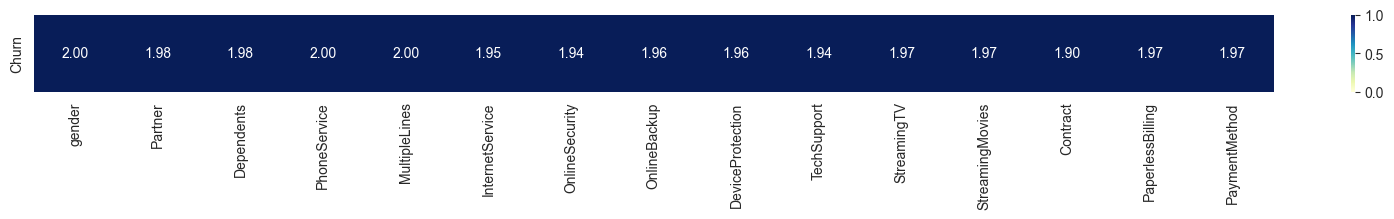

In [66]:
theilu = theilu.apply(pd.to_numeric, errors='coerce').astype(float).replace([np.inf, -np.inf], np.nan)
theilu.fillna(value=np.nan, inplace=True)
plt.figure(figsize=(20,1))
sns.heatmap(theilu, annot=True, fmt='.2f', cmap="YlGnBu", vmin=0, vmax=1, cbar=True)
plt.show()


<a id='6.6'></a>
## 6.6 Collinearity

For categorical variables, multicollinearity can be detected with **Spearman rank correlation coefficient** (ordinal variables) and **chi-square** test (nominal variables)

For categorical and a continuous variable, multicollinearity can be measured by t-test (if the categorical variable has 2 categories, parametric) or ANOVA (more than 2 categories, parametric)

Spearman's ρ was already performed, proceeding with chi-square 


<a id='6.6.1'></a>
### 6.6.1 Chi-Square

In [67]:
calculate_chi_square('PaymentMethod','MultipleLines')

Correlation between **PaymentMethod** and **MultipleLines**

p-value : 1.1367151062832025e-81, degree of freedom: 6
probability=0.950, critical=12.592, stat=392.514
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



In [68]:
calculate_chi_square('PaymentMethod','PhoneService')

Correlation between **PaymentMethod** and **PhoneService**

p-value : 0.8621473788722153, degree of freedom: 3
probability=0.950, critical=7.815, stat=0.747
Independent (fail to reject H0)
significance=0.050, p=0.862
Independent (fail to reject H0)
-----------------------------------



In [69]:
calculate_chi_square('PaymentMethod','Contract')

Correlation between **PaymentMethod** and **Contract**

p-value : 4.067638353787387e-213, degree of freedom: 6
probability=0.950, critical=12.592, stat=1001.582
Dependent (reject H0)
significance=0.050, p=0.000
Dependent (reject H0)
-----------------------------------



<a id='6.7'></a>
## 6.7 Visualization

### Tenure and MonthlyCharges Distribution

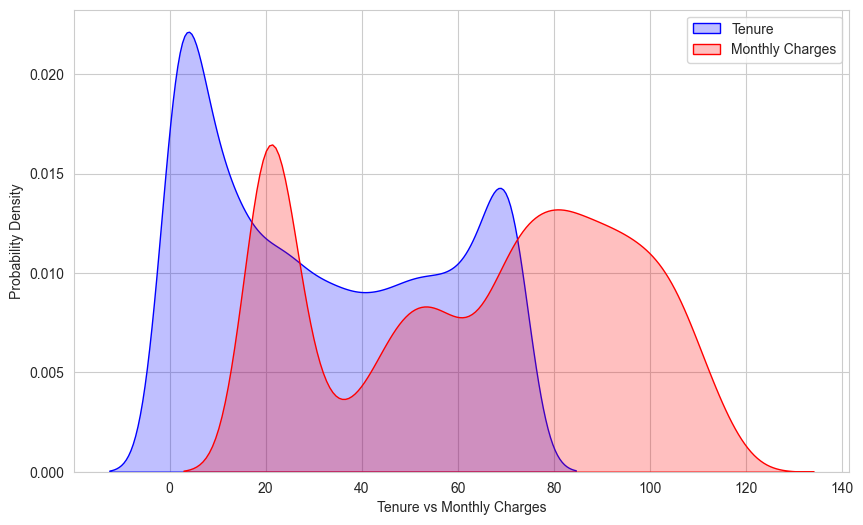

**Both are not normally distributed; skewed. Tenure has a 
bi-modal distribution.<br>Most users stayed for less than 20 months; 
Monthly Charges for most people is nearly 20 units.**

In [70]:
# Clean data for KDE
df_kde = df_churn[['tenure', 'MonthlyCharges']].apply(pd.to_numeric, errors='coerce').dropna()

plt.figure(figsize=(10, 6), dpi=100)
sns.kdeplot(data=df_kde, x='tenure',          color='b', fill=True, label='Tenure')
sns.kdeplot(data=df_kde, x='MonthlyCharges',  color='r', fill=True, label='Monthly Charges')

plt.xlabel('Tenure vs Monthly Charges')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

printmd("""**Both are not normally distributed; skewed. Tenure has a 
bi-modal distribution.<br>Most users stayed for less than 20 months; 
Monthly Charges for most people is nearly 20 units.**""")


In [71]:
# https://stackoverflow.com/a/65242391/11105356

df_g = df_churn.groupby(['StreamingTV', 'Churn']).size().reset_index()
df_g['percentage'] = df_churn.groupby(['StreamingTV', 'Churn']).size().groupby(level=0).apply(lambda x: 100 * x / float(x.sum())).values
df_g.columns = ['StreamingTV', 'Churn', 'Counts', 'Percentage']

fig = px.bar(df_g, x='StreamingTV', y='Counts', 
       color='Churn',
       color_discrete_map={
        'Yes': '#99D594',
        'No': '#FC8D59',
    }, 
    text=df_g['Percentage'].apply(lambda x: '{0:1.2f}%'.format(x)))

display(fig)
printmd("**Similar ratio between streamer vs non-streamer in churned users**")

**Similar ratio between streamer vs non-streamer in churned users**

### Contract and Churn

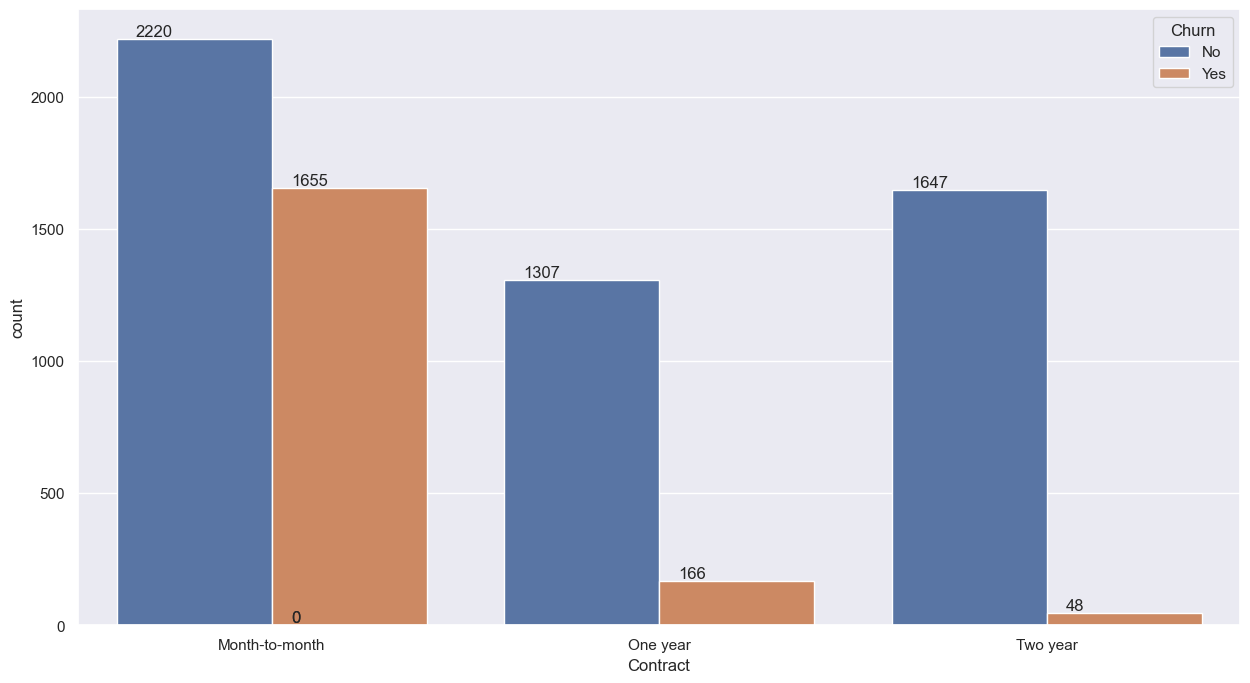

**Most churned users has Month-to-month contract**

In [72]:
sns.set(rc={'figure.figsize':(15,8)})
ax=sns.countplot(x='Contract',hue='Churn',data=df_churn)
for p in ax.patches:
    patch_height = p.get_height()
    if np.isnan(patch_height):
        patch_height = 0
    ax.annotate('{}'.format(int(patch_height)), (p.get_x()+0.05, patch_height+10))
plt.show()

printmd("**Most churned users has Month-to-month contract**")

### OnlineSecurity and Churn

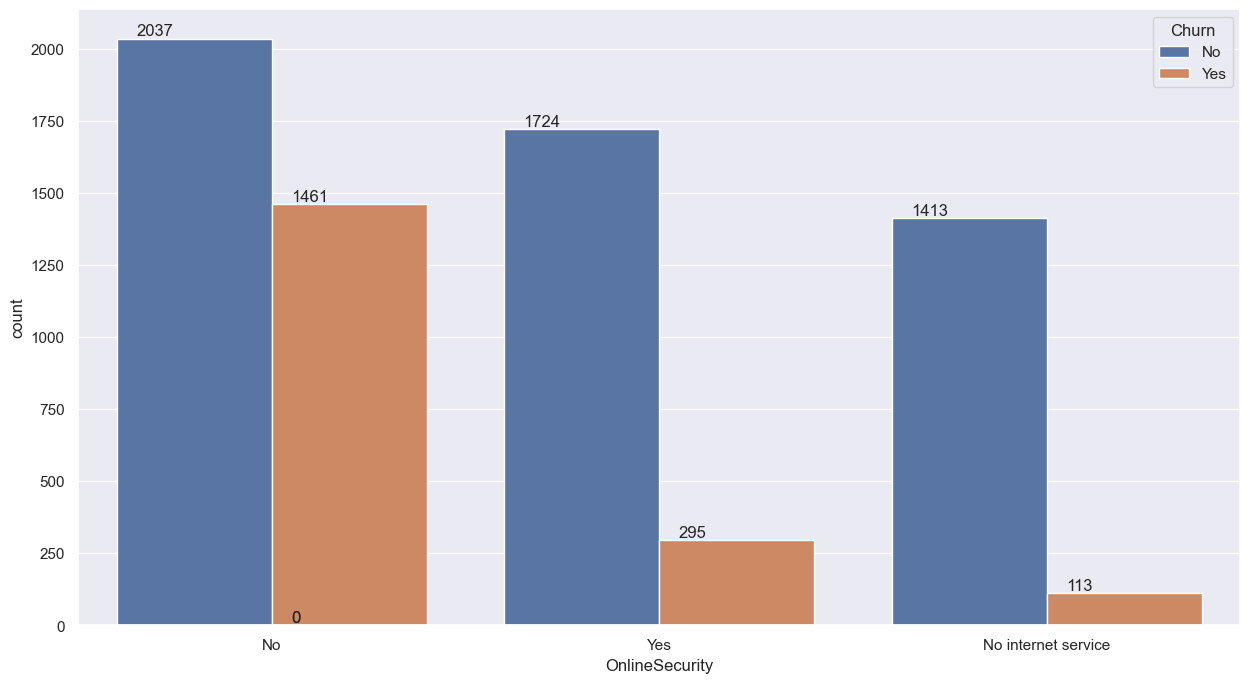

**Most churned users didn't have online security**

In [73]:
sns.set(rc={'figure.figsize':(15,8)})
ax=sns.countplot(x='OnlineSecurity',hue='Churn',data=df_churn)
for p in ax.patches:
    patch_height = p.get_height()
    if np.isnan(patch_height):
        patch_height = 0
    ax.annotate('{}'.format(int(patch_height)), (p.get_x()+0.05, patch_height+10))
plt.show()

printmd("**Most churned users didn't have online security**")

### Partner and Churn

**Most users who churned does not have a partner in contrast to the users who does**

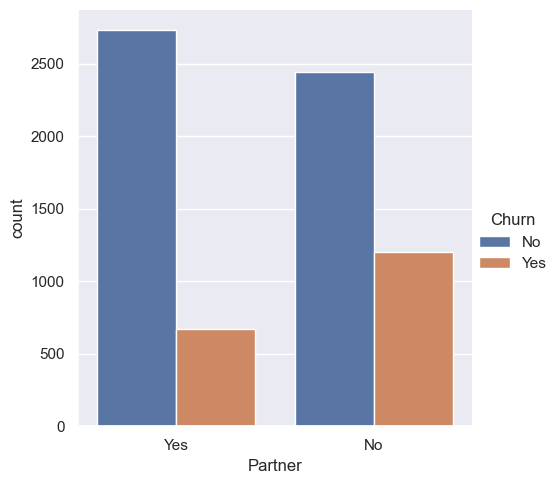

In [74]:
sns.catplot(x='Partner',hue='Churn',data=df_churn, kind="count");

printmd("**Most users who churned does not have a partner in contrast to the users who does**")

### Gender, TotalCharges and Churn

**Gender is uncorrelated with churn rate**

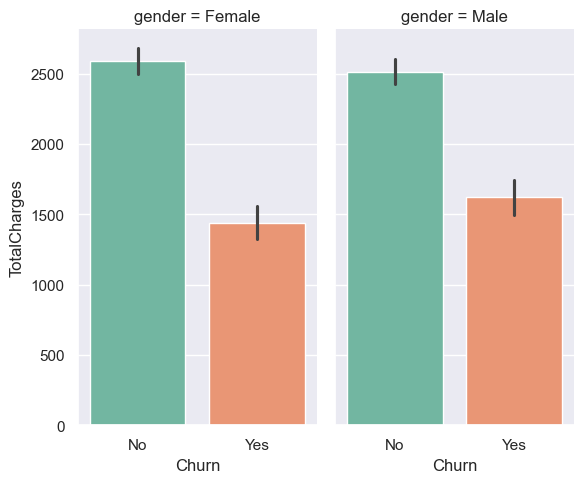

In [75]:
sns.catplot(x='Churn',y='TotalCharges', col = 'gender', data=df_churn,
                kind='bar', aspect=.6, palette='Set2')

printmd("**Gender is uncorrelated with churn rate**")

### Checking Outliers

In [76]:
px.box(df_churn, x="Churn", y="MonthlyCharges")

In [77]:
px.box(df_churn, x="Churn", y="TotalCharges")

In [78]:
px.box(df_churn, x="Churn", y="tenure")

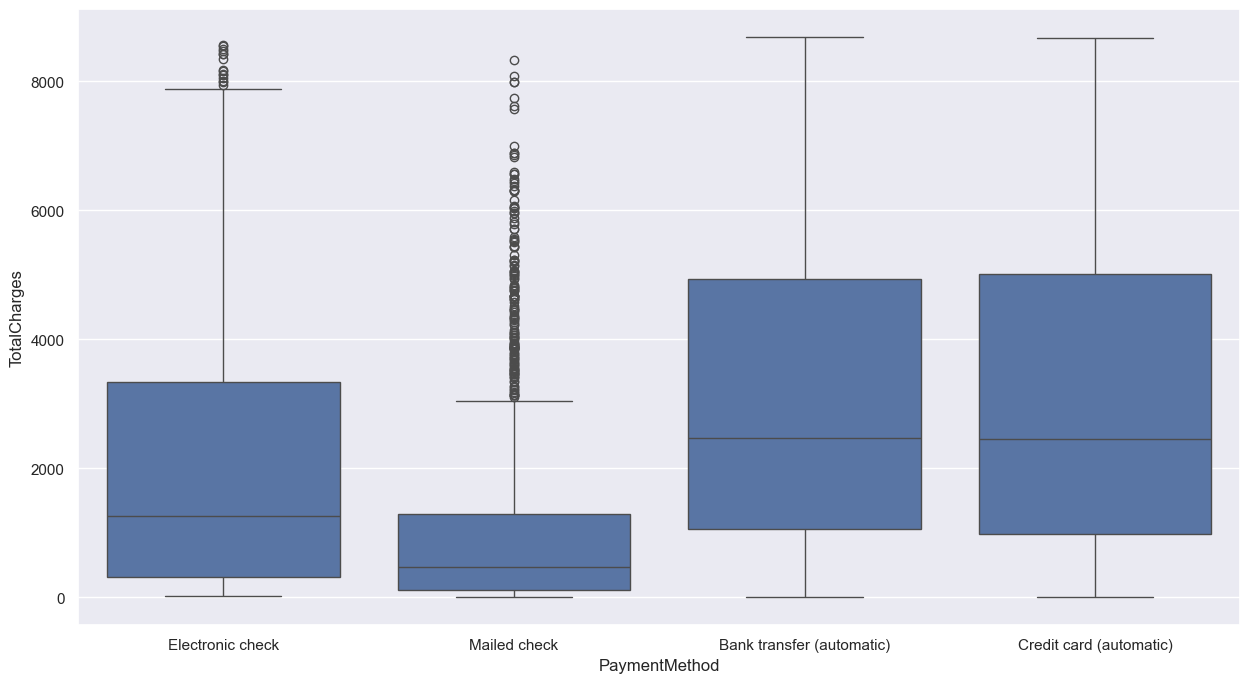

**Total Charges for many users are in extreme level in Mailed Check payment method**

In [79]:
plt.figure(figsize=(15,8))
ax = sns.boxplot(x="PaymentMethod", y="TotalCharges", data=df_churn)
plt.show()

printmd("**Total Charges for many users are in extreme level in Mailed Check payment method**")

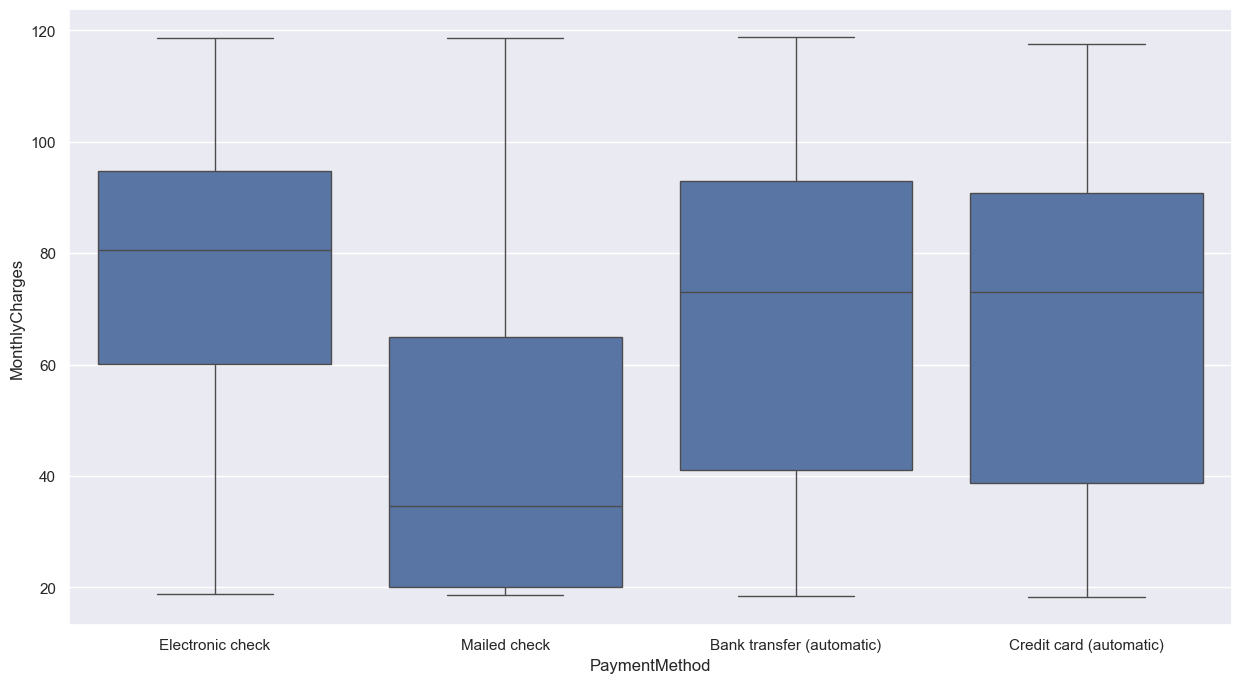

In [80]:
plt.figure(figsize=(15,8))
ax = sns.boxplot(x="PaymentMethod", y="MonthlyCharges", data=df_churn)
plt.show()